# AI-ML Assignment

## CIFAR-10 Image Classification using Convolutional Neural Networks (CNN)

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Data Understanding

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [3]:
# Load CIFAR-10 Dataset

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Dataset Loaded Successfully!")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2658s 16us/step
Dataset Loaded Successfully!


In [4]:
# Display dataset shape

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


In [5]:
# Display dataset shape

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


In [6]:
# Display class names

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


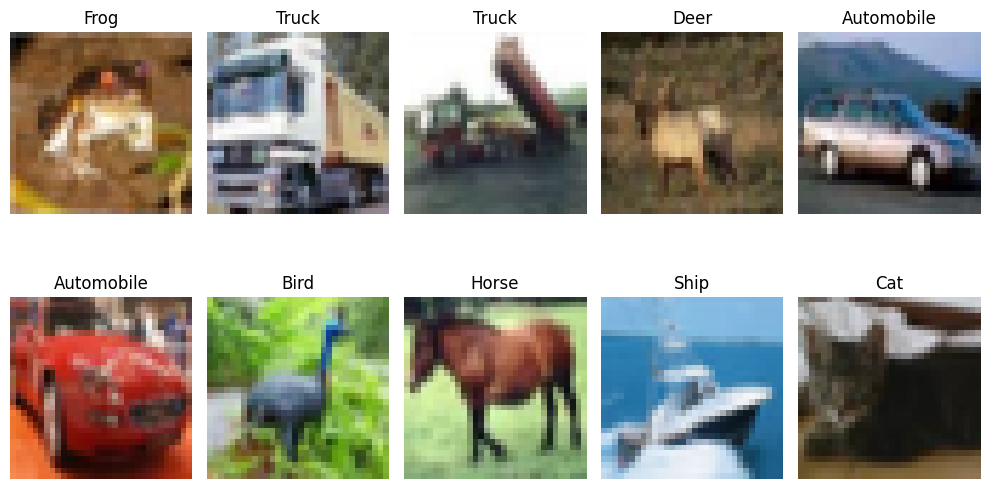

In [7]:
# Display sample images

plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2: Data Preprocessing

In [8]:
# Normalize pixel values

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Images normalized successfully!")

Images normalized successfully!


In [9]:
# One-Hot Encode Labels

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Labels encoded successfully!")

print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Labels encoded successfully!
Shape of y_train: (50000, 10)
Shape of y_test: (10000, 10)


In [10]:
print("Training Image Shape:", X_train.shape)
print("Testing Image Shape:", X_test.shape)

print("Training Label Shape:", y_train.shape)
print("Testing Label Shape:", y_test.shape)

print("\nSample Pixel Value:", X_train[0][0][0])

Training Image Shape: (50000, 32, 32, 3)
Testing Image Shape: (10000, 32, 32, 3)
Training Label Shape: (50000, 10)
Testing Label Shape: (10000, 10)

Sample Pixel Value: [0.23137255 0.24313726 0.24705882]


# Task 3: Model Development

In [11]:
# Build CNN Model

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

print("CNN Model Created Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Created Successfully!


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [15]:
# Train the CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 93ms/step - accuracy: 0.7105 - loss: 0.8291 - val_accuracy: 0.7050 - val_loss: 0.8560
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.7181 - loss: 0.8046 - val_accuracy: 0.7083 - val_loss: 0.8567
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.7291 - loss: 0.7779 - val_accuracy: 0.7098 - val_loss: 0.8559
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.7362 - loss: 0.7570 - val_accuracy: 0.7181 - val_loss: 0.8327
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.7410 - loss: 0.7353 - val_accuracy: 0.7168 - val_loss: 0.8476
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 84ms/step - accuracy: 0.7503 - loss: 0.7161 - val_accuracy: 0.7309 - val_loss: 0.8197
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.7540 - loss: 0.6983 - val_accuracy: 0.7229 - val_loss: 0.8260
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.7606 - loss: 0.6759 - 

# Task 4: Model Evaluation

In [16]:
# Evaluate the model

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7280 - loss: 0.8504
Test Loss: 0.8504225611686707
Test Accuracy: 0.7279999852180481


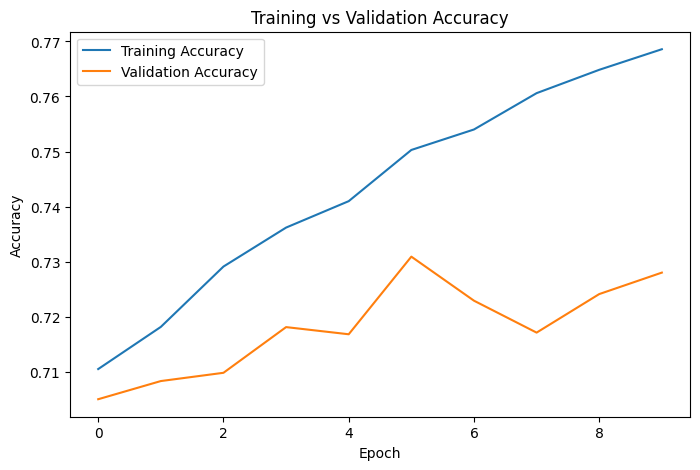

In [17]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

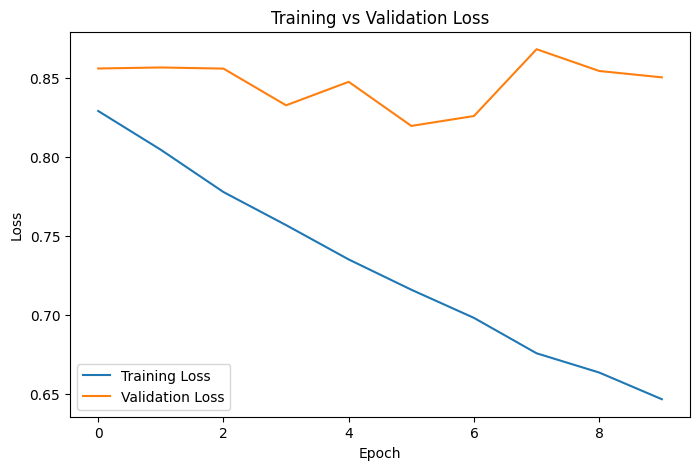

In [18]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


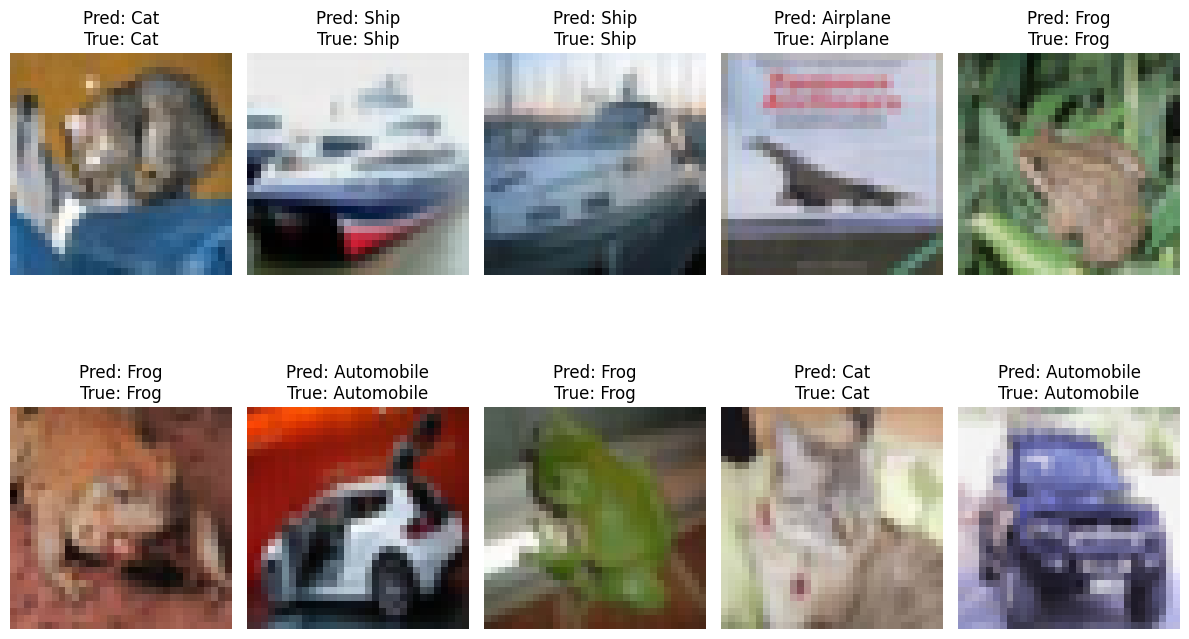

In [19]:
# Predict first 10 test images

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

plt.figure(figsize=(12,8))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[true_classes[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

1. The CNN model achieved good image classification accuracy on the CIFAR-10 dataset, demonstrating its ability to learn meaningful visual features.

2. The training and validation accuracy improved over successive epochs, while the loss decreased, indicating effective learning.

3. Some images were misclassified because certain CIFAR-10 classes, such as cats and dogs or trucks and automobiles, have visually similar characteristics.

# Task 5: Conclusion

The Convolutional Neural Network (CNN) was successfully developed to classify images from the CIFAR-10 dataset into ten different categories. The model was trained using normalized image data and achieved good classification accuracy on the test dataset. CNN automatically extracts important image features through convolution and pooling layers, making it highly effective for image classification tasks. The training and validation results demonstrate that the model can generalize well to unseen images. However, one limitation of this CNN model is that it may misclassify visually similar objects and requires considerable computational resources and training time. Using deeper architectures or data augmentation techniques can further improve the model's performance.